**DATA PREPARATION AND SCALING**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

train_data_path = "/content/DailyDelhiClimateTrain.csv"
test_data_path = "/content/DailyDelhiClimateTest.csv"

train_df = pd.read_csv(train_data_path)
test_df = pd.read_csv(test_data_path)

# Parse dates and set index
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df.set_index('date', inplace=True)
test_df.set_index('date', inplace=True)


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Combine train and test for consistent scaling
combined_df = pd.concat([train_df, test_df])

# Normalize the data using StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(combined_df)

# Split the data back into train and test
train_size = len(train_df)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]


In [ ]:
print(f"Train dataset size: {train_df.shape}")
print(f"Test dataset size: {test_df.shape}")


Train dataset size: (1462, 4)
Test dataset size: (114, 4)


In [ ]:
 sequence_length = 30

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length, 0])  # Assuming we want to predict the first feature (e.g., temperature)
    return np.array(X), np.array(y)


# Create sequences for training and testing
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

# Check shapes
print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test shape: X={X_test.shape}, y={y_test.shape}")

Train shape: X=(1432, 30, 4), y=(1432,)
Test shape: X=(84, 30, 4), y=(84,)


**LSTM MODEL**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# LSTM model definition
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1)  # Predicting a single value per sequence
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

lstm_model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
lstm_model.summary()

# Train the LSTM model
history_lstm = lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,569 (459.25 KB)

 Trainable params: 117,569 (459.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.2737 - mae: 0.3922 - val_loss: 0.1268 - val_mae: 0.3056
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0858 - mae: 0.2308 - val_loss: 0.1300 - val_mae: 0.3093
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0814 - mae: 0.2240 - val_loss: 0.1099 - val_mae: 0.2857
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0864 - mae: 0.2295 - val_loss: 0.1127 - val_mae: 0.2860
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0750 - mae: 0.2137 - val_loss: 0.0949 - val_mae: 0.2587
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0745 - mae: 0.2135 - val_loss: 0.1039 - val_mae: 0.2730
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0723 - mae: 0.2089 - val_loss: 0.0988 - val_mae: 0.2629
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0721 - mae: 0.2094 - val_loss: 0.0922 - val_mae: 0.2543
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0663 - mae:

**TRANSFORMER**

In [ ]:
from tensorflow.keras.layers import Input, MultiHeadAttention, LayerNormalization, Dense, Dropout, Add
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Lambda
from tensorflow.keras.layers import Embedding

def transformer_block(inputs, num_heads=4, ff_dim=32, dropout_rate=0.1):
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(inputs, inputs)
    attention_output = Dropout(dropout_rate)(attention_output)
    attention_output = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    ff_output = Dense(ff_dim, activation='relu')(attention_output)
    ff_output = Dropout(dropout_rate)(ff_output)
    ff_output = Dense(inputs.shape[-1])(ff_output)
    ff_output = LayerNormalization(epsilon=1e-6)(attention_output + ff_output)

    return ff_output

# Transformer model definition
def build_transformer_model(sequence_length, num_features):
    inputs = Input(shape=(sequence_length, num_features))
    x = transformer_block(inputs)  # Apply transformer block
    x = transformer_block(x)  # Apply another transformer block
    x = Lambda(lambda t: t[:, -1, :])(x)  # Use the last time step
    outputs = Dense(1)(x)  # Predict a single value
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

transformer_model = build_transformer_model(sequence_length, X_train.shape[2])
transformer_model.summary()

# Train the Transformer model
history_transformer = transformer_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 4)     │      2,436 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 4)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 4)     │          0 │ input_layer_1[0]… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 4)     │          8 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 32)    │        160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 32)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 4)     │        132 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 4)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 4)     │      2,436 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 4)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 4)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 32)    │        160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 32)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 4)     │        132 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 4)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,493 (21.46 KB)

 Trainable params: 5,493 (21.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - loss: 0.2065 - mae: 0.3647 - val_loss: 0.0962 - val_mae: 0.2418
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.1227 - mae: 0.2748 - val_loss: 0.0884 - val_mae: 0.2309
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1114 - mae: 0.2657 - val_loss: 0.0943 - val_mae: 0.2429
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1047 - mae: 0.2576 - val_loss: 0.0802 - val_mae: 0.2141
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1058 - mae: 0.2530 - val_loss: 0.0629 - val_mae: 0.1944
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0875 - mae: 0.2343 - val_loss: 0.0771 - val_mae: 0.2148
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0968 - mae: 0.2426 - val_loss: 0.0644 - val_mae: 0.1962
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0946 - mae: 0.2350 - val_loss: 0.0628 - val_mae: 0.2015
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0867 - ma

**HYPERPARAMETER TUNING**

In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 28.9 MB/s eta 0:00:00


In [ ]:
import optuna
from keras.optimizers import Adam

def objective(trial):
    units = trial.suggest_int('units', 32, 256)
    learning_rate = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    dropout_rate = trial.suggest_uniform('dropout', 0.1, 0.5)

    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)
    return history.history['val_loss'][-1]

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)


[I 2025-12-19 18:00:09,368] A new study created in memory with name: no-name-07e82870-17e8-40a5-ae77-a0713741cb14
/tmp/ipython-input-2807483165.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('lr', 1e-4, 1e-2)
/tmp/ipython-input-2807483165.py:7: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout', 0.1, 0.5)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.9489 - val_loss: 0.9476
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9683 - val_loss: 0.8726
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9227 - val_loss: 0.9388
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9586 - val_loss: 0.9261
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9680 - val_loss: 0.9038
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9260 - val_loss: 0.9017
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9141 - val_loss: 0.9415
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9565 - val_loss: 0.9217
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9766 - val_loss: 0.9210
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9677 - val_loss: 0.8872


[I 2025-12-19 18:00:16,899] Trial 0 finished with value: 0.8871526122093201 and parameters: {'units': 208, 'lr': 0.0021659177929294416, 'dropout': 0.21866774660354849}. Best is trial 0 with value: 0.8871526122093201.


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.9545 - val_loss: 0.9667
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9554 - val_loss: 0.9199
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9387 - val_loss: 0.9253
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9368 - val_loss: 0.9259
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9854 - val_loss: 0.9420
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9860 - val_loss: 0.9107
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9845 - val_loss: 0.9394
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9422 - val_loss: 0.9210
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9100 - val_loss: 0.9280
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9342 - val_loss: 0.9392


[I 2025-12-19 18:00:22,682] Trial 1 finished with value: 0.9391717910766602 and parameters: {'units': 78, 'lr': 0.007971619591531476, 'dropout': 0.3345617150688392}. Best is trial 0 with value: 0.8871526122093201.


...

[I 2025-12-19 18:00:49,893] Trial 7 finished with value: 0.9213553667068481 and parameters: {'units': 158, 'lr': 0.0012561374178704022, 'dropout': 0.12298664028936855}. Best is trial 0 with value: 0.8871526122093201.


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.9655 - val_loss: 0.9678
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9544 - val_loss: 0.9224
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9272 - val_loss: 0.9467
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0272 - val_loss: 0.9146
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9768 - val_loss: 0.8904
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9811 - val_loss: 0.9318
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9654 - val_loss: 0.9413
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9843 - val_loss: 0.9165
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9670 - val_loss: 0.9261
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9527 - val_loss: 0.8981


[I 2025-12-19 18:00:53,951] Trial 8 finished with value: 0.8980830907821655 and parameters: {'units': 248, 'lr': 0.0005407801640686387, 'dropout': 0.3637293994499212}. Best is trial 0 with value: 0.8871526122093201.


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.9867 - val_loss: 0.8842
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9558 - val_loss: 0.9831
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9473 - val_loss: 0.8606
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9551 - val_loss: 0.9198
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0092 - val_loss: 0.8937
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9590 - val_loss: 0.9351
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9627 - val_loss: 0.9376
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9457 - val_loss: 0.9477
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9824 - val_loss: 0.9053
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9485 - val_loss: 0.9111


[I 2025-12-19 18:00:58,458] Trial 9 finished with value: 0.9111371636390686 and parameters: {'units': 213, 'lr': 0.0002083933275135938, 'dropout': 0.14789670013797693}. Best is trial 0 with value: 0.8871526122093201.


**MODEL EVALUATION**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate LSTM
lstm_predictions = lstm_model.predict(X_test)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))
lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_r2 = r2_score(y_test, lstm_predictions)
print(f"LSTM - RMSE: {lstm_rmse}, MAE: {lstm_mae}, R²: {lstm_r2}")

# Evaluate Transformer
transformer_predictions = transformer_model.predict(X_test)
transformer_rmse = np.sqrt(mean_squared_error(y_test, transformer_predictions))
transformer_mae = mean_absolute_error(y_test, transformer_predictions)
transformer_r2 = r2_score(y_test, transformer_predictions)
print(f"Transformer - RMSE: {transformer_rmse}, MAE: {transformer_mae}, R²: {transformer_r2}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
LSTM - RMSE: 0.24253186562654125, MAE: 0.19518671841126434, R²: 0.9086672397872115
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 544ms/step
Transformer - RMSE: 0.26042584575520134, MAE: 0.2069559482180804, R²: 0.8946930257858557


## **ENHANCED TRANSFORMER MODEL**

In [ ]:
import numpy as np
from tensorflow.keras.layers import Layer
import tensorflow as tf

# Positional encoding layer
class PositionalEncoding(Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(max_len, d_model)

    def positional_encoding(self, max_len, d_model):
        angle_rads = self.get_angles(
            np.arange(max_len)[:, np.newaxis],
            np.arange(d_model)[np.newaxis, :],
            d_model,
        )
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    def call(self, inputs):
        return inputs + self.pos_encoding[:, : tf.shape(inputs)[1], :]

# Enhanced Transformer model
def build_enhanced_transformer(sequence_length, num_features, num_heads=4, ff_dim=64):
    inputs = Input(shape=(sequence_length, num_features))
    x = PositionalEncoding(sequence_length, num_features)(inputs)
    x = transformer_block(x, num_heads=num_heads, ff_dim=ff_dim, dropout_rate=0.2)
    x = transformer_block(x, num_heads=num_heads, ff_dim=ff_dim, dropout_rate=0.2)
    x = Lambda(lambda t: t[:, -1, :])(x)  # Use the last time step
    outputs = Dense(1)(x)  # Predict a single value
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Build and train the enhanced Transformer model
enhanced_transformer_model = build_enhanced_transformer(sequence_length, X_train.shape[2], num_heads=8, ff_dim=128)
enhanced_transformer_model.summary()

history_enhanced_transformer = enhanced_transformer_model.fit(
    X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test)
)


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 30, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 30, 4)     │          0 │ input_layer_12[0… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 4)     │     19,460 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 30, 4)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 4)     │          0 │ positional_encod… │
│                     │                   │            │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 30, 128)   │        640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 30, 128)   │          0 │ dense_16[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 30, 4)     │        516 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 4)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 4)     │     19,460 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 30, 4)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 4)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 30, 128)   │        640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 30, 128)   │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 30, 4)     │        516 │ dropout_23[0][0]

 Total params: 41,269 (161.21 KB)

 Trainable params: 41,269 (161.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - loss: 0.8727 - mae: 0.7089 - val_loss: 0.1402 - val_mae: 0.2946
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2008 - mae: 0.3560 - val_loss: 0.1206 - val_mae: 0.2698
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1724 - mae: 0.3312 - val_loss: 0.1197 - val_mae: 0.2826
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1676 - mae: 0.3230 - val_loss: 0.1086 - val_mae: 0.2702
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1574 - mae: 0.3134 - val_loss: 0.1273 - val_mae: 0.2817
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1534 - mae: 0.3081 - val_loss: 0.1238 - val_mae: 0.3014
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1597 - mae: 0.3153 - val_loss: 0.1160 - val_mae: 0.2901
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1289 - mae: 0.2835 - val_loss: 0.1333 - val_mae: 0.3084
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1231 - ma

## **ENHANCED LSTM MODEL**

In [ ]:
from tensorflow.keras.layers import Bidirectional

# Enhanced LSTM model
def create_enhanced_lstm_model(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

enhanced_lstm_model = create_enhanced_lstm_model((X_train.shape[1], X_train.shape[2]))
enhanced_lstm_model.summary()

history_enhanced_lstm = enhanced_lstm_model.fit(
    X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       136,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,433 (853.25 KB)

 Trainable params: 218,433 (853.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.2343 - mae: 0.3708 - val_loss: 0.0969 - val_mae: 0.2521
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0837 - mae: 0.2244 - val_loss: 0.0871 - val_mae: 0.2432
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0720 - mae: 0.2127 - val_loss: 0.0810 - val_mae: 0.2364
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0730 - mae: 0.2135 - val_loss: 0.0806 - val_mae: 0.2381
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0728 - mae: 0.2074 - val_loss: 0.0782 - val_mae: 0.2400
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0755 - mae: 0.2125 - val_loss: 0.0715 - val_mae: 0.2209
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0649 - mae: 0.2001 - val_loss: 0.0752 - val_mae: 0.2203
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0659 - mae: 0.2017 - val_loss: 0.0742 - val_mae: 0.2136
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.069

## **Advanced Hyperparameter Optimization**

In [ ]:
def transformer_objective(trial):
    num_heads = trial.suggest_int("num_heads", 2, 8)
    ff_dim = trial.suggest_int("ff_dim", 32, 256)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)

    model = build_enhanced_transformer(sequence_length, X_train.shape[2], num_heads, ff_dim)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)
    return history.history['val_loss'][-1]

study = optuna.create_study(direction="minimize")
study.optimize(transformer_objective, n_trials=20)
best_params = study.best_params

print("Best Transformer Params:", best_params)


[I 2025-12-19 18:03:13,125] A new study created in memory with name: no-name-179231da-8962-44c8-96ed-2d26bb7c89cd
[I 2025-12-19 18:03:34,422] Trial 0 finished with value: 0.09757783263921738 and parameters: {'num_heads': 4, 'ff_dim': 74, 'dropout_rate': 0.22568051106916875, 'learning_rate': 0.00438562959313959}. Best is trial 0 with value: 0.09757783263921738.
[I 2025-12-19 18:03:55,917] Trial 1 finished with value: 0.1911468505859375 and parameters: {'num_heads': 5, 'ff_dim': 110, 'dropout_rate': 0.4516140711230031, 'learning_rate': 0.008460971185931494}. Best is trial 0 with value: 0.09757783263921738.
[I 2025-12-19 18:04:18,259] Trial 2 finished with value: 0.10734409093856812 and parameters: {'num_heads': 4, 'ff_dim': 217, 'dropout_rate': 0.49504079419555624, 'learning_rate': 0.003361992696282073}. Best is trial 0 with value: 0.09757783263921738.
[I 2025-12-19 18:04:40,447] Trial 3 finished with value: 0.09539541602134705 and parameters: {'num_heads': 3, 'ff_dim': 138, 'dropout_rat

Best Transformer Params: {'num_heads': 2, 'ff_dim': 69, 'dropout_rate': 0.3194099183051442, 'learning_rate': 0.002335288829193238}


### **REGULARIZATION**

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

enhanced_transformer_model.fit(
    X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[reduce_lr]
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0775 - mae: 0.2173 - val_loss: 0.0829 - val_mae: 0.2397 - learning_rate: 0.0010
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0658 - mae: 0.2063 - val_loss: 0.0770 - val_mae: 0.2298 - learning_rate: 0.0010
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0692 - mae: 0.2077 - val_loss: 0.0951 - val_mae: 0.2552 - learning_rate: 0.0010
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0683 - mae: 0.2040 - val_loss: 0.0586 - val_mae: 0.2094 - learning_rate: 0.0010
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0758 - mae: 0.2147 - val_loss: 0.0772 - val_mae: 0.2348 - learning_rate: 0.0010
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0665 - mae: 0.2025 - val_loss: 0.0710 - val_mae: 0.2248 - learning_rate: 0.0010
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0621 - mae: 0.2012 - val_loss: 0.0718 - val_mae: 0.2251 - learning_rate: 0.0010
Epoch 8/50
45/45 ━━━

## **METRICS EVALUATION**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate LSTM model
lstm_predictions = enhanced_lstm_model.predict(X_test)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))
lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_r2 = r2_score(y_test, lstm_predictions)
print(f"LSTM - RMSE: {lstm_rmse:.4f}, MAE: {lstm_mae:.4f}, R²: {lstm_r2:.4f}")

# Evaluate Transformer model
transformer_predictions = enhanced_transformer_model.predict(X_test)
transformer_rmse = np.sqrt(mean_squared_error(y_test, transformer_predictions))
transformer_mae = mean_absolute_error(y_test, transformer_predictions)
transformer_r2 = r2_score(y_test, transformer_predictions)
print(f"Transformer - RMSE: {transformer_rmse:.4f}, MAE: {transformer_mae:.4f}, R²: {transformer_r2:.4f}")



1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
LSTM - RMSE: 0.2410, MAE: 0.1963, R²: 0.9098
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step
Transformer - RMSE: 0.2335, MAE: 0.2010, R²: 0.9153


## **ENSEMBLE MODEL**

In [ ]:
def optimize_ensemble_weights(trial):
    lstm_weight = trial.suggest_uniform("lstm_weight", 0, 1)
    ensemble_predictions = (
        lstm_weight * lstm_predictions + (1 - lstm_weight) * transformer_predictions
    )
    return np.sqrt(mean_squared_error(y_test, ensemble_predictions))

study = optuna.create_study(direction="minimize")
study.optimize(optimize_ensemble_weights, n_trials=10)
best_lstm_weight = study.best_params["lstm_weight"]
best_transformer_weight = 1 - best_lstm_weight

ensemble_predictions = (best_lstm_weight * lstm_predictions + best_transformer_weight * transformer_predictions)

# Evaluate Ensemble
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_predictions))
ensemble_mae = mean_absolute_error(y_test, ensemble_predictions)
ensemble_r2 = r2_score(y_test, ensemble_predictions)

print(f"Ensemble - RMSE: {ensemble_rmse}, MAE: {ensemble_mae}, R²: {ensemble_r2}")

[I 2025-12-19 18:12:11,954] A new study created in memory with name: no-name-5e9ae79b-9f68-4cb8-834e-9328c78a4779
/tmp/ipython-input-2878912464.py:2: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  lstm_weight = trial.suggest_uniform("lstm_weight", 0, 1)
[I 2025-12-19 18:12:11,958] Trial 0 finished with value: 0.22532670056656964 and parameters: {'lstm_weight': 0.4773469832691454}. Best is trial 0 with value: 0.22532670056656964.
/tmp/ipython-input-2878912464.py:2: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  lstm_weight = trial.suggest_uniform("lstm_weight", 0, 1)
[I 2025-12-19 18:12:11,960] Trial 1 finished with value: 0.22519107754025983 and parameters: {'lstm_weight': 0.4433570571390698}. Best is trial

Ensemble - RMSE: 0.22519107754025983, MAE: 0.18887608280345164, R²: 0.9212607405457756


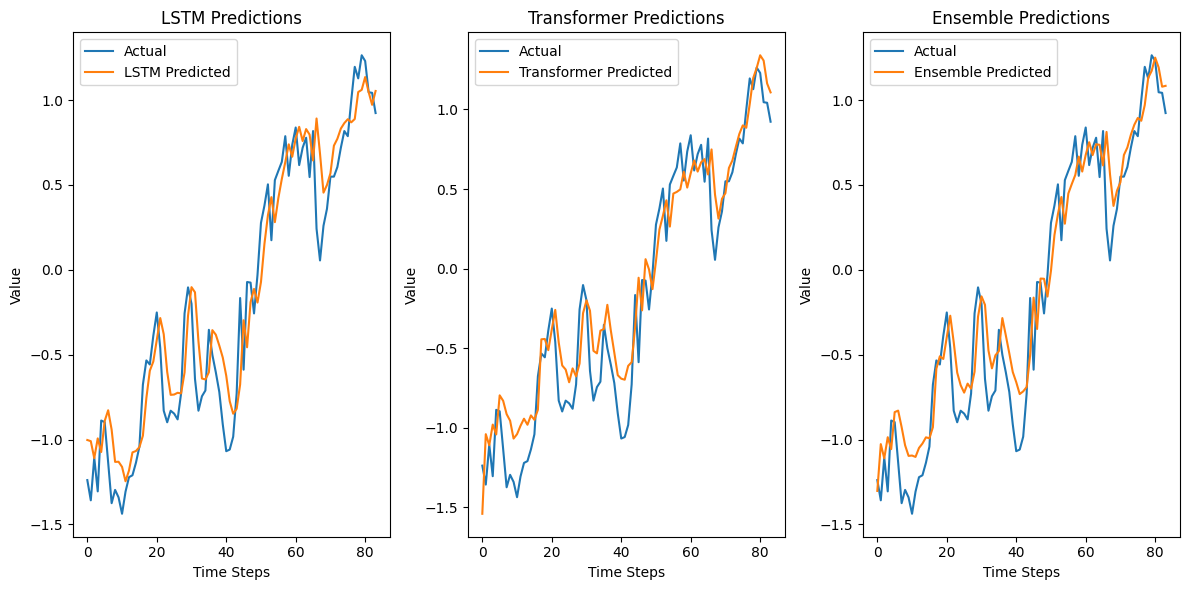

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# LSTM Predictions
plt.subplot(1, 3, 1)
plt.plot(y_test, label='Actual')
plt.plot(lstm_predictions, label='LSTM Predicted')
plt.title('LSTM Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()

# Transformer Predictions
plt.subplot(1, 3, 2)
plt.plot(y_test, label='Actual')
plt.plot(transformer_predictions, label='Transformer Predicted')
plt.title('Transformer Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()

# Ensemble Predictions
plt.subplot(1, 3, 3)
plt.plot(y_test, label='Actual')
plt.plot(ensemble_predictions, label='Ensemble Predicted')
plt.title('Ensemble Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

